# Baseline Comparison - Logistic Regression

Author: Quirin Lex


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Global Settings
RANDOM_STATE = 42
PARAM_GRID = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
TELCO_PATH = "../data/processed/telco_clean.csv"
BANK_PATH = "../data/processed/bank_clean.csv"
ECOM_PATH = "../data/processed/ecom_clean.csv"

---
## 1. Dataset: Telco Customer Churn

In [2]:
# Load and prepare data
df_telco = pd.read_csv(TELCO_PATH).drop(columns=['customerID'])
df_telco_prep = pd.get_dummies(df_telco, drop_first=True)

X_telco = df_telco_prep.drop(columns=['Churn'])
y_telco = df_telco_prep['Churn']

X_telco_train, X_telco_valid, y_telco_train, y_telco_valid = train_test_split(
    X_telco, y_telco, test_size=0.2, random_state=RANDOM_STATE
)

### Scaling and Model Training

In [3]:
# Scaling
telco_scaler = preprocessing.StandardScaler().fit(X_telco_train)
X_telco_train_scaled = telco_scaler.transform(X_telco_train)
X_telco_valid_scaled = telco_scaler.transform(X_telco_valid)

# GridSearchCV for Logistic Regression
grid_telco = GridSearchCV(LogisticRegression(max_iter=1000), PARAM_GRID, cv=5)
grid_telco.fit(X_telco_train_scaled, y_telco_train)
lr_telco = grid_telco.best_estimator_

# Cross-validation score
cv_scores_telco = cross_val_score(lr_telco, X_telco_train_scaled, y_telco_train, cv=5)

print(f"Best Parameter C: {grid_telco.best_params_}")
print(f"Mean CV score: {cv_scores_telco.mean():.4f}")

# Calculate accuracy
acc_telco_train = lr_telco.score(X_telco_train_scaled, y_telco_train) * 100
acc_telco_valid = lr_telco.score(X_telco_valid_scaled, y_telco_valid) * 100

Best Parameter C: {'C': 10}
Mean CV score: 0.8021


### Model Evaluation

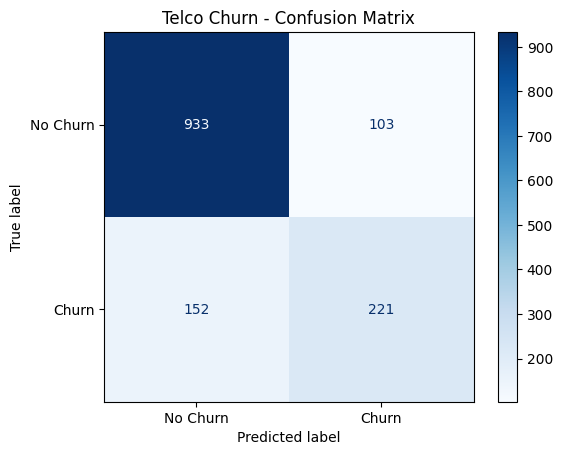

In [4]:
y_telco_pred = lr_telco.predict(X_telco_valid_scaled)
ConfusionMatrixDisplay.from_predictions(y_telco_valid, y_telco_pred, display_labels=['No Churn', 'Churn'], cmap='Blues')
plt.title('Telco Churn - Confusion Matrix')
plt.show()

---
## 2. Dataset: E-Commerce Shopping

In [5]:
df_online = pd.read_csv(ECOM_PATH)
df_online_prep = pd.get_dummies(df_online, drop_first=True)

X_online = df_online_prep.drop(columns=['Revenue'])
y_online = df_online_prep['Revenue']

X_online_train, X_online_valid, y_online_train, y_online_valid = train_test_split(
    X_online, y_online, test_size=0.2, random_state=RANDOM_STATE
)

### Scaling and Model Training

In [6]:
online_scaler = preprocessing.StandardScaler().fit(X_online_train)
X_online_train_scaled = online_scaler.transform(X_online_train)
X_online_valid_scaled = online_scaler.transform(X_online_valid)

grid_online = GridSearchCV(LogisticRegression(max_iter=1000), PARAM_GRID, cv=5)
grid_online.fit(X_online_train_scaled, y_online_train)
lr_online = grid_online.best_estimator_

cv_scores_online = cross_val_score(lr_online, X_online_train_scaled, y_online_train, cv=5)

print(f"Best Parameter C: {grid_online.best_params_}")
acc_online_train = lr_online.score(X_online_train_scaled, y_online_train) * 100
acc_online_valid = lr_online.score(X_online_valid_scaled, y_online_valid) * 100

Best Parameter C: {'C': 10}


### Model Evaluation

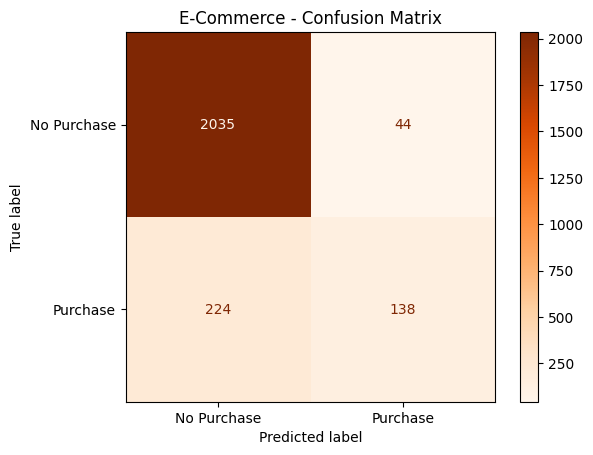

In [7]:
y_online_pred = lr_online.predict(X_online_valid_scaled)
ConfusionMatrixDisplay.from_predictions(y_online_valid, y_online_pred, display_labels=['No Purchase', 'Purchase'], cmap='Oranges')
plt.title('E-Commerce - Confusion Matrix')
plt.show()

---
## 3. Dataset: Bank Marketing

In [8]:
df_bank = pd.read_csv(BANK_PATH)
df_bank_prep = pd.get_dummies(df_bank, drop_first=True)

X_bank = df_bank_prep.drop(columns=['y'])
y_bank = df_bank_prep['y']

X_bank_train, X_bank_valid, y_bank_train, y_bank_valid = train_test_split(
    X_bank, y_bank, test_size=0.2, random_state=RANDOM_STATE
)

### Scaling and Model Training

In [9]:
bank_scaler = preprocessing.StandardScaler().fit(X_bank_train)
X_bank_train_scaled = bank_scaler.transform(X_bank_train)
X_bank_valid_scaled = bank_scaler.transform(X_bank_valid)

grid_bank = GridSearchCV(LogisticRegression(max_iter=1000), PARAM_GRID, cv=5)
grid_bank.fit(X_bank_train_scaled, y_bank_train)
lr_bank = grid_bank.best_estimator_

cv_scores_bank = cross_val_score(lr_bank, X_bank_train_scaled, y_bank_train, cv=5)

print(f"Best Parameter C: {grid_bank.best_params_}")
acc_bank_train = lr_bank.score(X_bank_train_scaled, y_bank_train) * 100
acc_bank_valid = lr_bank.score(X_bank_valid_scaled, y_bank_valid) * 100

Best Parameter C: {'C': 1}


### Model Evaluation

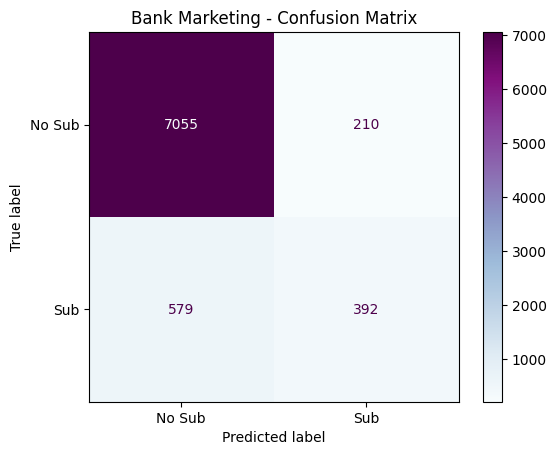

In [10]:
y_bank_pred = lr_bank.predict(X_bank_valid_scaled)
ConfusionMatrixDisplay.from_predictions(y_bank_valid, y_bank_pred, display_labels=['No Sub', 'Sub'], cmap='BuPu')
plt.title('Bank Marketing - Confusion Matrix')
plt.show()

---
## Summary and Comparison

In [14]:
summary_data = {
    'Dataset': ['Telco Churn', 'Online Shoppers', 'Bank Marketing'],
    'Features': [X_telco.shape[1], X_online.shape[1], X_bank.shape[1]],
    'Best C': [grid_telco.best_params_['C'], grid_online.best_params_['C'], grid_bank.best_params_['C']],
    'Train Accuracy': [f"{acc_telco_train:.2f}%", f"{acc_online_train:.2f}%", f"{acc_bank_train:.2f}%"],
    'Valid Accuracy': [f"{acc_telco_valid:.2f}%", f"{acc_online_valid:.2f}%", f"{acc_bank_valid:.2f}%"],
    'Mean CV Score': [
        f"{(cv_scores_telco.mean()):.4f}",
        f"{(cv_scores_online.mean()):.4f}",
        f"{(cv_scores_bank.mean()):.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data).set_index('Dataset')
print("Model Performance Summary (Baseline: Logistic Regression):")
display(summary_df)

Model Performance Summary (Baseline: Logistic Regression):


,Features,Best C,Train Accuracy,Valid Accuracy,Mean CV Score
Dataset,,,,,
Telco Churn,30,10,80.21%,81.90%,0.8021
Online Shoppers,26,10,88.19%,89.02%,0.8815
Bank Marketing,46,1,91.28%,90.42%,0.9119
